In [4]:
import sys
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import time

In [5]:
"""
Лабораторная работа №5: Q-обучение с использованием нейронных сетей
Вариант: TensorFlow

Среда: CartPole-v1
"""

# Настройка виртуального дисплея
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

# Импорт TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

# Отключаем предупреждения
tf.get_logger().setLevel('ERROR')
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [6]:
# СОЗДАНИЕ СРЕДЫ
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Параметры среды
n_actions = int(env.action_space.n)
state_dim = int(env.observation_space.shape[0])

print(f"Количество действий: {n_actions}")
print(f"Размерность состояния: {state_dim}")

Количество действий: 2
Размерность состояния: 4


In [7]:
# 1. СОЗДАНИЕ НЕЙРОННОЙ СЕТИ

def build_q_network(state_dim, n_actions):
    """Создает упрощенную нейронную сеть для быстрого обучения"""
    model = keras.Sequential([
        L.InputLayer(shape=(state_dim,)),
        L.Dense(64, activation='relu'),
        L.Dense(64, activation='relu'),
        L.Dense(n_actions, activation='linear')
    ])
    return model

# Создаем сеть
q_network = build_q_network(state_dim, n_actions)
target_network = build_q_network(state_dim, n_actions)
target_network.set_weights(q_network.get_weights())

print("\nСтруктура сети:")
q_network.summary()


Структура сети:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 2. ЭПСИЛОН-ЖАДНАЯ ПОЛИТИКА

@tf.function
def get_q_values(state_batch):
    """Быстрое получение Q-значений"""
    return q_network(state_batch, training=False)

def get_action(state, epsilon=0.0):
    """Быстрый выбор действия"""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)

    # Преобразуем в тензор и получаем Q-значения
    state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
    q_values = get_q_values(state_tensor).numpy()[0]
    return int(np.argmax(q_values))

In [9]:
# 3. ГИПЕРПАРАМЕТРЫ
GAMMA = 0.99
LEARNING_RATE = 0.001
MEMORY_SIZE = 5000  # Уменьшен для скорости
BATCH_SIZE = 32
TARGET_UPDATE_FREQ = 50  # Чаще обновляем
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.99  # Быстрее уменьшаем
TRAIN_EPISODES = 300  # Меньше эпизодов

# Оптимизатор
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

In [10]:
# 4. БУФЕР ВОСПРОИЗВЕДЕНИЯ

class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int32),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

memory = ReplayBuffer(MEMORY_SIZE)

In [11]:
# 5. ФУНКЦИЯ ОБУЧЕНИЯ

@tf.function
def train_step(states, actions, rewards, next_states, dones):
    """Оптимизированный шаг обучения"""
    with tf.GradientTape() as tape:
        # Q-значения для текущих состояний
        q_values = q_network(states, training=True)

        # Выбираем Q-значения для выполненных действий
        batch_size = tf.shape(actions)[0]
        indices = tf.stack([tf.range(batch_size), actions], axis=1)
        predicted_q = tf.gather_nd(q_values, indices)

        # Q-значения для следующих состояний
        next_q_values = target_network(next_states, training=False)
        next_max_q = tf.reduce_max(next_q_values, axis=1)

        # TD-target
        target_q = rewards + GAMMA * next_max_q * (1.0 - dones)

        # Функция потерь
        loss = tf.reduce_mean(tf.square(target_q - predicted_q))

    # Обновление весов
    gradients = tape.gradient(loss, q_network.trainable_variables)
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    return loss

In [12]:
# 6. ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ

def train_agent():
    epsilon = EPSILON_START
    episode_rewards = []
    episode_lengths = []
    losses = []
    best_reward = 0

    print("\n" + "="*50)
    print("НАЧАЛО ОБУЧЕНИЯ (TensorFlow - оптимизированная версия)")
    print("="*50)

    start_time = time.time()

    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        episode_reward = 0
        episode_losses = []
        step = 0

        while True:
            # Выбор действия
            action = get_action(state, epsilon)

            # Выполнение действия
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Сохранение перехода
            memory.push(state, action, reward, next_state, done)

            state = next_state
            episode_reward += reward
            step += 1

            # Обучение (только если есть достаточно данных)
            if len(memory) >= BATCH_SIZE:
                s_batch, a_batch, r_batch, ns_batch, d_batch = memory.sample(BATCH_SIZE)
                loss = train_step(s_batch, a_batch, r_batch, ns_batch, d_batch)
                episode_losses.append(loss.numpy())

            if done:
                break

        # Сохранение статистики
        episode_rewards.append(episode_reward)
        episode_lengths.append(step)
        if episode_losses:
            losses.append(np.mean(episode_losses))

        # Обновление целевой сети
        if (episode + 1) % TARGET_UPDATE_FREQ == 0:
            target_network.set_weights(q_network.get_weights())

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Вывод прогресса
        avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else episode_reward

        if (episode + 1) % 20 == 0:  # Выводим каждые 20 эпизодов
            elapsed = time.time() - start_time
            print(f"Эпизод {episode + 1:3d}: Награда = {episode_reward:6.2f}, "
                  f"Ср. (10) = {avg_reward:6.2f}, "
                  f"Eps = {epsilon:.3f}, "
                  f"Время = {elapsed:.1f}с")

        # Сохранение лучшей модели
        if avg_reward > best_reward and avg_reward > 100:
            best_reward = avg_reward
            q_network.save('best_q_network_tf.keras')
            print(f"  *** Новая лучшая модель! Средняя награда = {avg_reward:.2f} ***")

        # Ранняя остановка
        if avg_reward >= 195:  # CartPole-v1 считается решенным при 195
            print(f"\n*** ЗАДАЧА РЕШЕНА! Средняя награда = {avg_reward:.2f} ***")
            print(f"Обучение завершено после {episode + 1} эпизодов")
            break

    total_time = time.time() - start_time
    print(f"\nОбщее время обучения: {total_time:.1f} секунд")

    return episode_rewards, episode_lengths, losses

# Запуск обучения
episode_rewards, episode_lengths, losses = train_agent()




НАЧАЛО ОБУЧЕНИЯ (TensorFlow - оптимизированная версия)
Эпизод  20: Награда =  21.00, Ср. (10) =  24.20, Eps = 0.818, Время = 1.9с
Эпизод  40: Награда =  10.00, Ср. (10) =  15.40, Eps = 0.669, Время = 2.5с
Эпизод  60: Награда =  14.00, Ср. (10) =  12.90, Eps = 0.547, Время = 3.1с
Эпизод  80: Награда =  10.00, Ср. (10) =  11.80, Eps = 0.448, Время = 3.6с
Эпизод 100: Награда =  11.00, Ср. (10) =  11.10, Eps = 0.366, Время = 4.1с
Эпизод 120: Награда =  10.00, Ср. (10) =  13.70, Eps = 0.299, Время = 4.8с
Эпизод 140: Награда =   9.00, Ср. (10) =  11.10, Eps = 0.245, Время = 5.3с
Эпизод 160: Награда =  41.00, Ср. (10) =  29.20, Eps = 0.200, Время = 6.3с
Эпизод 180: Награда =  79.00, Ср. (10) =  59.80, Eps = 0.164, Время = 9.4с
Эпизод 200: Награда = 119.00, Ср. (10) =  94.50, Eps = 0.134, Время = 13.6с
  *** Новая лучшая модель! Средняя награда = 105.40 ***
  *** Новая лучшая модель! Средняя награда = 115.10 ***
  *** Новая лучшая модель! Средняя награда = 134.50 ***
  *** Новая лучшая модель

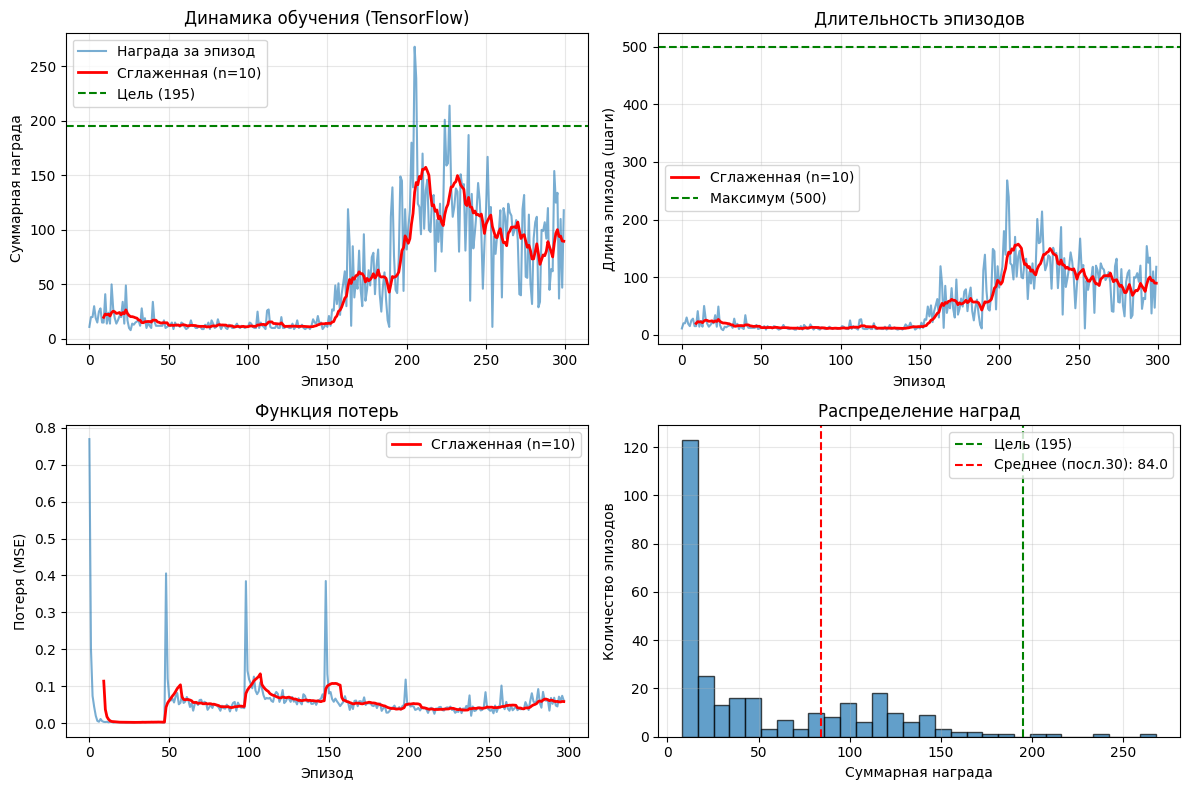

In [13]:
# 7. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# График наград
axes[0, 0].plot(episode_rewards, alpha=0.6, label='Награда за эпизод')
window = 10
if len(episode_rewards) >= window:
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(range(window-1, len(episode_rewards)), smoothed_rewards,
                    'r-', linewidth=2, label=f'Сглаженная (n={window})')
axes[0, 0].axhline(y=195, color='g', linestyle='--', label='Цель (195)')
axes[0, 0].set_xlabel('Эпизод')
axes[0, 0].set_ylabel('Суммарная награда')
axes[0, 0].set_title('Динамика обучения (TensorFlow)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График длины эпизодов
axes[0, 1].plot(episode_lengths, alpha=0.6)
if len(episode_lengths) >= window:
    smoothed_lengths = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(range(window-1, len(episode_lengths)), smoothed_lengths,
                    'r-', linewidth=2, label=f'Сглаженная (n={window})')
axes[0, 1].axhline(y=500, color='g', linestyle='--', label='Максимум (500)')
axes[0, 1].set_xlabel('Эпизод')
axes[0, 1].set_ylabel('Длина эпизода (шаги)')
axes[0, 1].set_title('Длительность эпизодов')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График потерь
if losses:
    axes[1, 0].plot(losses, alpha=0.6)
    if len(losses) >= window:
        smoothed_losses = np.convolve(losses, np.ones(window)/window, mode='valid')
        axes[1, 0].plot(range(window-1, len(losses)), smoothed_losses,
                        'r-', linewidth=2, label=f'Сглаженная (n={window})')
    axes[1, 0].set_xlabel('Эпизод')
    axes[1, 0].set_ylabel('Потеря (MSE)')
    axes[1, 0].set_title('Функция потерь')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Гистограмма наград
axes[1, 1].hist(episode_rewards, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=195, color='g', linestyle='--', label='Цель (195)')
if episode_rewards:
    axes[1, 1].axvline(x=np.mean(episode_rewards[-30:]), color='r',
                       linestyle='--', label=f'Среднее (посл.30): {np.mean(episode_rewards[-30:]):.1f}')
axes[1, 1].set_xlabel('Суммарная награда')
axes[1, 1].set_ylabel('Количество эпизодов')
axes[1, 1].set_title('Распределение наград')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results_tf.png', dpi=150)
plt.show()

In [15]:
# 8. БЫСТРОЕ ТЕСТИРОВАНИЕ

def test_agent(n_episodes=5, render=False):
    """Быстрое тестирование обученного агента"""
    print("ТЕСТИРОВАНИЕ ОБУЧЕННОГО АГЕНТА")

    test_env = gym.make("CartPole-v1", render_mode="human" if render else "rgb_array")

    total_rewards = []

    for episode in range(n_episodes):
        state, _ = test_env.reset()
        episode_reward = 0
        step = 0

        while True:
            action = get_action(state, epsilon=0.0)
            next_state, reward, terminated, truncated, _ = test_env.step(action)
            done = terminated or truncated

            state = next_state
            episode_reward += reward
            step += 1

            if done:
                print(f"Эпизод {episode + 1}: награда = {episode_reward:.0f}, шагов = {step}")
                total_rewards.append(episode_reward)
                break

    print(f"\nРезультаты тестирования:")
    print(f"  Средняя награда: {np.mean(total_rewards):.2f}")
    print(f"  Стандартное отклонение: {np.std(total_rewards):.2f}")

    test_env.close()
    return total_rewards

# Тестирование
test_rewards = test_agent(n_episodes=5, render=False)

print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
if episode_rewards:
    print(f"Максимальная награда: {max(episode_rewards):.2f}")
    print(f"Средняя награда за последние 30 эпизодов: {np.mean(episode_rewards[-30:]):.2f}")
print(f"Количество эпизодов: {len(episode_rewards)}")

ТЕСТИРОВАНИЕ ОБУЧЕННОГО АГЕНТА
Эпизод 1: награда = 174, шагов = 174
Эпизод 2: награда = 134, шагов = 134
Эпизод 3: награда = 125, шагов = 125
Эпизод 4: награда = 190, шагов = 190
Эпизод 5: награда = 229, шагов = 229

Результаты тестирования:
  Средняя награда: 170.40
  Стандартное отклонение: 37.99
ОБУЧЕНИЕ ЗАВЕРШЕНО
Максимальная награда: 268.00
Средняя награда за последние 30 эпизодов: 84.03
Количество эпизодов: 300


PyTorch version: 2.10.0+cpu
CUDA available: False
Используемое устройство: cpu
Количество действий: 2
Размерность состояния: 4


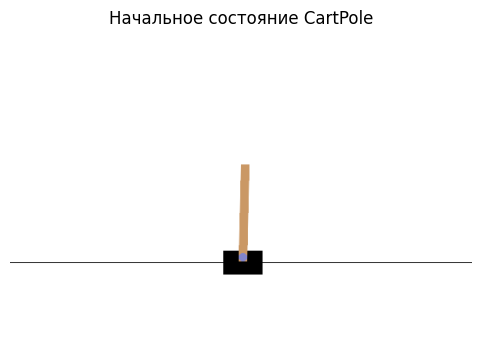

In [16]:
"""
Лабораторная работа №5: Q-обучение с использованием нейронных сетей
Вариант: PyTorch

Среда: CartPole-v1
Задача: обучить агента балансировать шест с помощью Deep Q-Learning
"""

# Настройка виртуального дисплея
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

# Импорт PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Установка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

# Создание среды - используем CartPole-v1
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()

# Параметры среды
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print(f"Количество действий: {n_actions}")
print(f"Размерность состояния: {state_dim}")

# Визуализация начального состояния
plt.figure(figsize=(6, 4))
plt.title("Начальное состояние CartPole")
plt.imshow(env.render())
plt.axis('off')
plt.show()
env.close()

In [17]:
# 1. Создание нейронной сети для аппроксимации Q-функции

class QNetwork(nn.Module):
    """
    Нейронная сеть для аппроксимации Q-значений.

    Архитектура:
    - Входной слой: размерность состояния (4)
    - Полносвязные слои с ReLU активацией
    - Выходной слой: линейная активация, размер = количество действий
    """

    def __init__(self, state_dim, n_actions, hidden_sizes=[64, 64, 32]):
        super(QNetwork, self).__init__()

        # Создание слоев
        self.fc1 = nn.Linear(state_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], n_actions)

        # Инициализация весов для лучшей сходимости
        self._initialize_weights()

    def _initialize_weights(self):
        """Инициализация весов с использованием Xavier uniform"""
        for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        """
        Прямой проход сети.

        Args:
            x: входное состояние (batch_size, state_dim)

        Returns:
            Q-значения для каждого действия
        """
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)  # Линейная активация на выходе
        return x

# Создание сетей
q_network = QNetwork(state_dim, n_actions).to(device)
target_network = QNetwork(state_dim, n_actions).to(device)

# Инициализация целевой сети
target_network.load_state_dict(q_network.state_dict())

# Оптимизатор и функция потерь
optimizer = optim.Adam(q_network.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("\nСтруктура нейронной сети (PyTorch):")
print(q_network)


Структура нейронной сети (PyTorch):
QNetwork(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)


In [18]:
# 2. Эпсилон-жадная политика

def get_action(state, network, epsilon=0.0, device=device):
    """
    Выбор действия с использованием эпсилон-жадной политики.

    Args:
        state: текущее состояние (numpy array)
        network: нейронная сеть для предсказания Q-значений
        epsilon: вероятность выбора случайного действия
        device: устройство для вычислений

    Returns:
        action: выбранное действие (int)
    """
    # С вероятностью epsilon выбираем случайное действие
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)

    # Иначе выбираем действие с максимальным Q-значением
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = network(state_tensor)
        action = int(torch.argmax(q_values).cpu().numpy())

    return action

# Проверка эпсилон-жадной политики
def test_epsilon_greedy():
    """Тестирование корректности эпсилон-жадной политики"""
    s = env.reset()[0]
    for eps in [0.0, 0.1, 0.5, 1.0]:
        action_counts = np.zeros(n_actions)
        n_tests = 10000

        for _ in range(n_tests):
            a = get_action(s, q_network, epsilon=eps)
            action_counts[a] += 1

        best_action = np.argmax(action_counts)
        expected_best = n_tests * (1 - eps + eps / n_actions)
        expected_other = n_tests * (eps / n_actions)

        assert abs(action_counts[best_action] - expected_best) < 200, \
            f"Ошибка при epsilon={eps}"

        print(f'epsilon={eps} - тест пройден')

print("\nТестирование эпсилон-жадной политики:")
test_epsilon_greedy()


Тестирование эпсилон-жадной политики:
epsilon=0.0 - тест пройден
epsilon=0.1 - тест пройден
epsilon=0.5 - тест пройден
epsilon=1.0 - тест пройден


In [19]:
# 3. Гиперпараметры

GAMMA = 0.99
MEMORY_SIZE = 10000
BATCH_SIZE = 32
TARGET_UPDATE_FREQ = 100
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
TRAIN_EPISODES = 500

In [20]:
# 4. Буфер воспроизведения опыта

class ReplayBuffer:
    """Буфер воспроизведения опыта"""

    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states, dtype=np.float32),
                np.array(actions, dtype=np.int64),
                np.array(rewards, dtype=np.float32),
                np.array(next_states, dtype=np.float32),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

# Инициализация буфера
memory = ReplayBuffer(MEMORY_SIZE)

In [21]:
# 5. Функция обучения

def train_step(states, actions, rewards, next_states, dones, gamma):
    """
    Один шаг обучения.

    Args:
        states: батч состояний
        actions: батч действий
        rewards: батч наград
        next_states: батч следующих состояний
        dones: флаги завершения эпизода
        gamma: коэффициент дисконтирования

    Returns:
        loss_value: значение функции потерь
    """
    # Конвертация в тензоры PyTorch
    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).to(device)

    # Q-значения для текущих состояний
    q_values = q_network(states)

    # Выбор Q-значений для выполненных действий
    q_values_for_actions = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    # Q-значения для следующих состояний (целевая сеть)
    with torch.no_grad():
        next_q_values = target_network(next_states)
        next_max_q = next_q_values.max(1)[0]

        # TD-target
        target_q = rewards + gamma * next_max_q * (1 - dones)

    # Вычисление потерь
    loss = loss_fn(q_values_for_actions, target_q)

    # Обновление весов
    optimizer.zero_grad()
    loss.backward()
    # Ограничение градиентов для стабильности
    torch.nn.utils.clip_grad_norm_(q_network.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()

In [22]:
# 6. Основной цикл обучения

def train_agent():
    """Основной цикл обучения агента"""

    epsilon = EPSILON_START
    episode_rewards = []
    episode_lengths = []
    losses = []
    best_reward = 0

    print("НАЧАЛО ОБУЧЕНИЯ (PyTorch)")

    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        episode_reward = 0
        episode_losses = []
        step = 0

        while True:
            # Выбор действия
            action = get_action(state, q_network, epsilon)

            # Выполнение действия
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Сохранение перехода
            memory.push(state, action, reward, next_state, done)

            # Обновление состояния
            state = next_state
            episode_reward += reward
            step += 1

            # Обучение
            if len(memory) >= BATCH_SIZE:
                states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch = memory.sample(BATCH_SIZE)
                loss = train_step(states_batch, actions_batch, rewards_batch,
                                 next_states_batch, dones_batch, GAMMA)
                episode_losses.append(loss)

            if done:
                break

        # Сохранение статистики
        episode_rewards.append(episode_reward)
        episode_lengths.append(step)
        if episode_losses:
            losses.append(np.mean(episode_losses))

        # Обновление целевой сети
        if (episode + 1) % TARGET_UPDATE_FREQ == 0:
            target_network.load_state_dict(q_network.state_dict())
            print(f"  -> Целевая сеть обновлена")

        # Уменьшение epsilon
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Вывод прогресса
        avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else episode_reward

        if (episode + 1) % 50 == 0:
            print(f"Эпизод {episode + 1:3d}: Награда = {episode_reward:6.2f}, "
                  f"Ср. награда (10) = {avg_reward:6.2f}, "
                  f"Epsilon = {epsilon:.4f}, "
                  f"Длина = {step:3d}")

        # Сохранение лучшей модели
        if avg_reward > best_reward and avg_reward > 100:
            best_reward = avg_reward
            torch.save(q_network.state_dict(), 'best_q_network_pt.pt')
            print(f"  *** Сохранена лучшая модель! Средняя награда = {avg_reward:.2f} ***")

        # Ранняя остановка
        if avg_reward >= 200:
            print(f"\n*** Достигнута цель! Средняя награда = {avg_reward:.2f} ***")
            print(f"Обучение завершено после {episode + 1} эпизодов")
            break

    return episode_rewards, episode_lengths, losses

# Запуск обучения
episode_rewards, episode_lengths, losses = train_agent()

НАЧАЛО ОБУЧЕНИЯ (PyTorch)
Эпизод  50: Награда =  11.00, Ср. награда (10) =  15.70, Epsilon = 0.7783, Длина =  11
  -> Целевая сеть обновлена
Эпизод 100: Награда =  11.00, Ср. награда (10) =  15.00, Epsilon = 0.6058, Длина =  11
Эпизод 150: Награда =  11.00, Ср. награда (10) =  13.70, Epsilon = 0.4715, Длина =  11
  -> Целевая сеть обновлена
Эпизод 200: Награда =  10.00, Ср. награда (10) =  10.70, Epsilon = 0.3670, Длина =  10
Эпизод 250: Награда =  11.00, Ср. награда (10) =  11.70, Epsilon = 0.2856, Длина =  11
  -> Целевая сеть обновлена
Эпизод 300: Награда =  29.00, Ср. награда (10) =  16.50, Epsilon = 0.2223, Длина =  29
Эпизод 350: Награда =  25.00, Ср. награда (10) =  22.00, Epsilon = 0.1730, Длина =  25
  -> Целевая сеть обновлена
Эпизод 400: Награда =  11.00, Ср. награда (10) =  17.90, Epsilon = 0.1347, Длина =  11
Эпизод 450: Награда =  27.00, Ср. награда (10) =  25.70, Epsilon = 0.1048, Длина =  27
  -> Целевая сеть обновлена
Эпизод 500: Награда =  22.00, Ср. награда (10) =  2

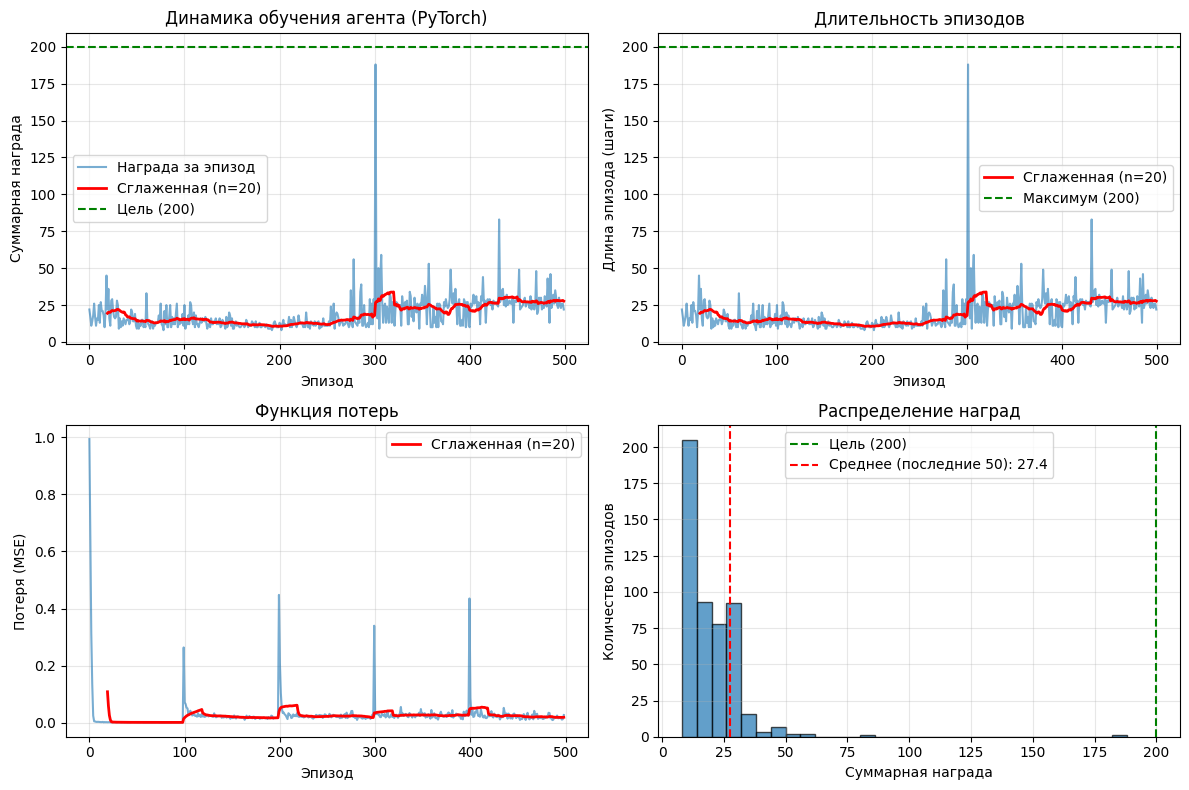

In [23]:
# 7. Визуализация результатов

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# График наград
axes[0, 0].plot(episode_rewards, alpha=0.6, label='Награда за эпизод')
window = 20
if len(episode_rewards) >= window:
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(range(window-1, len(episode_rewards)), smoothed_rewards,
                    'r-', linewidth=2, label=f'Сглаженная (n={window})')
axes[0, 0].axhline(y=200, color='g', linestyle='--', label='Цель (200)')
axes[0, 0].set_xlabel('Эпизод')
axes[0, 0].set_ylabel('Суммарная награда')
axes[0, 0].set_title('Динамика обучения агента (PyTorch)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График длины эпизодов
axes[0, 1].plot(episode_lengths, alpha=0.6)
if len(episode_lengths) >= window:
    smoothed_lengths = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(range(window-1, len(episode_lengths)), smoothed_lengths,
                    'r-', linewidth=2, label=f'Сглаженная (n={window})')
axes[0, 1].axhline(y=200, color='g', linestyle='--', label='Максимум (200)')
axes[0, 1].set_xlabel('Эпизод')
axes[0, 1].set_ylabel('Длина эпизода (шаги)')
axes[0, 1].set_title('Длительность эпизодов')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График потерь
if losses:
    axes[1, 0].plot(losses, alpha=0.6)
    if len(losses) >= window:
        smoothed_losses = np.convolve(losses, np.ones(window)/window, mode='valid')
        axes[1, 0].plot(range(window-1, len(losses)), smoothed_losses,
                        'r-', linewidth=2, label=f'Сглаженная (n={window})')
    axes[1, 0].set_xlabel('Эпизод')
    axes[1, 0].set_ylabel('Потеря (MSE)')
    axes[1, 0].set_title('Функция потерь')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Гистограмма наград
axes[1, 1].hist(episode_rewards, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=200, color='g', linestyle='--', label='Цель (200)')
axes[1, 1].axvline(x=np.mean(episode_rewards[-50:]), color='r',
                   linestyle='--', label=f'Среднее (последние 50): {np.mean(episode_rewards[-50:]):.1f}')
axes[1, 1].set_xlabel('Суммарная награда')
axes[1, 1].set_ylabel('Количество эпизодов')
axes[1, 1].set_title('Распределение наград')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results_pt.png', dpi=150)
plt.show()

ТЕСТИРОВАНИЕ ОБУЧЕННОГО АГЕНТА (PyTorch)
Эпизод 1: награда = 24, шагов = 24
Эпизод 2: награда = 22, шагов = 22
Эпизод 3: награда = 25, шагов = 25
Эпизод 4: награда = 24, шагов = 24
Эпизод 5: награда = 25, шагов = 25
Эпизод 6: награда = 24, шагов = 24
Эпизод 7: награда = 24, шагов = 24
Эпизод 8: награда = 25, шагов = 25
Эпизод 9: награда = 24, шагов = 24
Эпизод 10: награда = 25, шагов = 25

Результаты тестирования:
  Средняя награда: 24.20
  Стандартное отклонение: 0.87
  Максимальная награда: 25.00
  Минимальная награда: 22.00


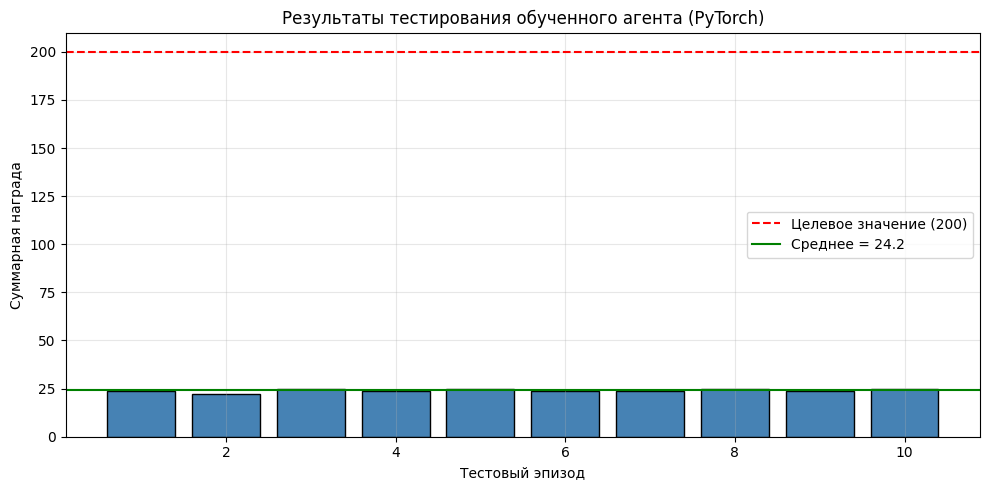

ОБУЧЕНИЕ ЗАВЕРШЕНО (PyTorch)
Максимальная награда: 188.00
Средняя награда за последние 50 эпизодов: 27.38
Количество эпизодов: 500


In [24]:
# 8. Тестирование обученного агента

def test_agent(n_episodes=10, render=False):
    """Тестирование обученного агента"""
    print("ТЕСТИРОВАНИЕ ОБУЧЕННОГО АГЕНТА (PyTorch)")


    test_env = gym.make("CartPole-v1", render_mode="human" if render else "rgb_array")

    total_rewards = []

    for episode in range(n_episodes):
        state, _ = test_env.reset()
        episode_reward = 0
        step = 0

        while True:
            if render:
                test_env.render()

            action = get_action(state, q_network, epsilon=0.0)
            next_state, reward, terminated, truncated, _ = test_env.step(action)
            done = terminated or truncated

            state = next_state
            episode_reward += reward
            step += 1

            if done:
                print(f"Эпизод {episode + 1}: награда = {episode_reward:.0f}, шагов = {step}")
                total_rewards.append(episode_reward)
                break

    print(f"\nРезультаты тестирования:")
    print(f"  Средняя награда: {np.mean(total_rewards):.2f}")
    print(f"  Стандартное отклонение: {np.std(total_rewards):.2f}")
    print(f"  Максимальная награда: {np.max(total_rewards):.2f}")
    print(f"  Минимальная награда: {np.min(total_rewards):.2f}")

    test_env.close()
    return total_rewards

# Тестирование
test_rewards = test_agent(n_episodes=10, render=False)

# Визуализация тестовых результатов
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(test_rewards) + 1), test_rewards, color='steelblue', edgecolor='black')
plt.axhline(y=200, color='r', linestyle='--', label='Целевое значение (200)')
plt.axhline(y=np.mean(test_rewards), color='g', linestyle='-',
            label=f'Среднее = {np.mean(test_rewards):.1f}')
plt.xlabel('Тестовый эпизод')
plt.ylabel('Суммарная награда')
plt.title('Результаты тестирования обученного агента (PyTorch)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('test_results_pt.png', dpi=150)
plt.show()

print("ОБУЧЕНИЕ ЗАВЕРШЕНО (PyTorch)")
print(f"Максимальная награда: {max(episode_rewards):.2f}")
print(f"Средняя награда за последние 50 эпизодов: {np.mean(episode_rewards[-50:]):.2f}")
print(f"Количество эпизодов: {len(episode_rewards)}")